In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib
%matplotlib inline

# Explore the data 
Obtain newest release at: https://exoplanetarchive.ipac.caltech.edu/cgi-bin/TblView/nph-tblView?app=ExoTbls&config=PS


In [10]:
filename = "PS_2025.04.15_13.40.30.csv" # change this to your newly downloaded file
data = pd.read_csv(filename, skiprows=124)
data

,pl_name,hostname,pl_letter,default_flag,sy_snum,sy_pnum,sy_mnum,cb_flag,discoverymethod,disc_year,...,sy_vmagerr2,sy_kmag,sy_kmagerr1,sy_kmagerr2,sy_gaiamag,sy_gaiamagerr1,sy_gaiamagerr2,rowupdate,pl_pubdate,releasedate
0,11 Com b,11 Com,b,1,2,1,0,0,Radial Velocity,2007,...,-0.023,2.282,0.346,-0.346,4.44038,0.003848,-0.003848,2023-09-19,2023-08,2023-09-19
1,11 UMi b,11 UMi,b,1,1,1,0,0,Radial Velocity,2009,...,-0.005,1.939,0.270,-0.270,4.56216,0.003903,-0.003903,2018-09-04,2017-03,2018-09-06
2,14 And b,14 And,b,1,1,1,0,0,Radial Velocity,2008,...,-0.023,2.331,0.240,-0.240,4.91781,0.002826,-0.002826,2023-09-19,2023-08,2023-09-19
3,14 Her b,14 Her,b,1,1,2,0,0,Radial Velocity,2002,...,-0.023,4.714,0.016,-0.016,6.38300,0.000351,-0.000351,2023-06-12,2022-09,2023-06-12
4,16 Cyg B b,16 Cyg B,b,1,3,1,0,0,Radial Velocity,1996,...,-0.016,4.651,0.016,-0.016,6.06428,0.000603,-0.000603,2018-09-04,2017-03,2018-09-06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5864,ups And b,ups And,b,1,2,3,0,0,Radial Velocity,1996,...,-0.023,2.859,0.274,-0.274,3.98687,0.008937,-0.008937,2019-01-28,2011-01,2019-01-31
5865,ups And c,ups And,c,1,2,3,0,0,Radial Velocity,1999,...,-0.023,2.859,0.274,-0.274,3.98687,0.008937,-0.008937,2019-01-28,2011-01,2019-01-31
5866,ups And d,ups And,d,1,2,3,0,0,Radial Velocity,1999,...,-0.023,2.859,0.274,-0.274,3.98687,0.008937,-0.008937,2019-01-28,2011-01,2019-01-31
5867,ups Leo b,ups Leo,b,1,1,1,0,0,Radial Velocity,2021,...,-0.023,2.184,0.248,-0.248,4.03040,0.008513,-0.008513,2022-01-10,2021-12,2022-01-10


In [3]:
for item in data.columns: print (item)

pl_name
hostname
pl_letter
default_flag
sy_snum
sy_pnum
sy_mnum
cb_flag
discoverymethod
disc_year
disc_refname
disc_pubdate
disc_locale
disc_facility
disc_telescope
disc_instrument
soltype
pl_controv_flag
pl_refname
pl_orbper
pl_orbpererr1
pl_orbpererr2
pl_orbperlim
pl_orbsmax
pl_orbsmaxerr1
pl_orbsmaxerr2
pl_orbsmaxlim
pl_rade
pl_radeerr1
pl_radeerr2
pl_radelim
pl_radj
pl_radjerr1
pl_radjerr2
pl_radjlim
pl_bmasse
pl_bmasseerr1
pl_bmasseerr2
pl_bmasselim
pl_bmassj
pl_bmassjerr1
pl_bmassjerr2
pl_bmassjlim
pl_bmassprov
pl_orbeccen
pl_orbeccenerr1
pl_orbeccenerr2
pl_orbeccenlim
pl_insol
pl_insolerr1
pl_insolerr2
pl_insollim
pl_eqt
pl_eqterr1
pl_eqterr2
pl_eqtlim
pl_orbincl
pl_orbinclerr1
pl_orbinclerr2
pl_orbincllim
pl_tranmid
pl_tranmiderr1
pl_tranmiderr2
pl_tranmidlim
ttv_flag
st_refname
st_spectype
st_teff
st_tefferr1
st_tefferr2
st_tefflim
st_rad
st_raderr1
st_raderr2
st_radlim
st_mass
st_masserr1
st_masserr2
st_masslim
st_met
st_meterr1
st_meterr2
st_metlim
st_metratio
st_logg
st_log

## Example: make scatter plots from the database

In [4]:
# Solar System planet data, for comparison

data_ss = pd.DataFrame()

data_ss['label'] = ['M','V', ' E', ' Mars', ' J', ' S','U','N','P']
data_ss['discoverymethod'] = ['Imaging','Imaging', 'Imaging', 'Imaging', 'Imaging', 'Imaging','Imaging','Imaging','Imaging']
data_ss['pl_orbsmax'] = [0.38, 0.72, 1.0, 1.52, 5.2, 9.537, 19.189, 30.0699, 39.48]
data_ss['pl_bmasse'] = [0.05, 0.81, 1.0, 0.107, 317, 95, 14.5, 17.204, 0.002]
data_ss['extrap_mass'] = [0.05, 0.81, 1.0, 0.107, 317, 95, 14.5, 17.204, 0.002]
data_ss['disc_year'] = [0, 0, 0, 0, 0, 0, 1781, 1846, 1930]
data_ss['pl_orbper'] = [88, 225, 365, 687, 12 * 365, 29 * 365, 84 * 365, 165 * 265, 248 * 365]
data_ss['default_flag'] = [1,1,1,1,1,1,1,1,1]

dicdatlist = []


In [5]:
## Extrapolate masses for exoplanets if you don't have them

dat2 = data
truemass = []
for i, item in enumerate(dat2['pl_bmasse'].values):
    if pd.notnull(dat2['pl_bmasse'].values[i]):
        truemass.append(item)
    else: 
        truemass.append(dat2['pl_rade'].values[i]**2.1)
data['extrap_mass'] = truemass

Text(200000.0, 20000.0, 'Image created by J. Becker')

<Figure size 1200x700 with 0 Axes>

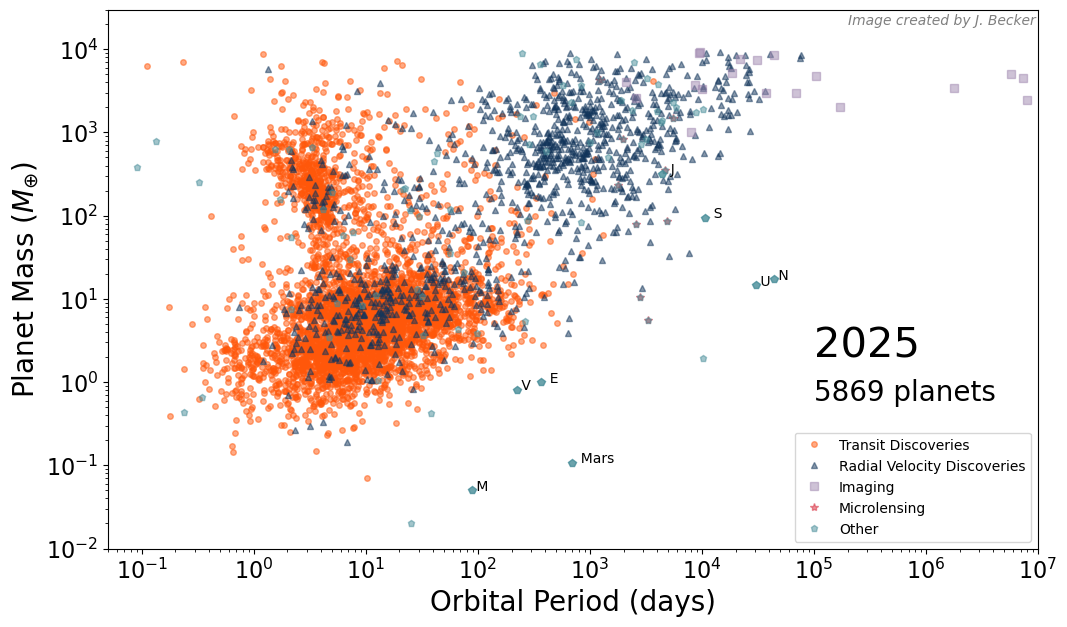

In [6]:
plt.figure(figsize=(12,7))
colorlist = ["#ff570a","#12355b","#9f87af","#d72638","#468c98", '#98B06F']
yeartested = 2025


colused = 'grey'
x_axis_name = 'pl_orbper'
y_axis_name = 'extrap_mass'
alphaused = 0.5

plt.figure(figsize=(12,7))
idxglobal = (dat2['default_flag'] ==1)
idx1 = (dat2['discoverymethod'] == 'Transit') & idxglobal
plt.plot(dat2.loc[idx1][x_axis_name], dat2.loc[idx1][y_axis_name],'o', markersize = 4, color=colorlist[0], alpha = alphaused, label="Transit Discoveries")
idx2 = (dat2['discoverymethod'] == 'Radial Velocity') & idxglobal
plt.plot(dat2.loc[idx2][x_axis_name], dat2.loc[idx2][y_axis_name],'^', color=colorlist[1], markersize = 5, alpha = alphaused, label="Radial Velocity Discoveries")
idx3 = (dat2['discoverymethod'] == 'Imaging')& idxglobal
plt.plot(dat2.loc[idx3][x_axis_name], dat2.loc[idx3][y_axis_name],'s', color=colorlist[2], alpha = alphaused, label="Imaging")
idx4 = (dat2['discoverymethod'] == 'Microlensing')& idxglobal
plt.plot(dat2.loc[idx4][x_axis_name], dat2.loc[idx4][y_axis_name],'*', color=colorlist[3], alpha = alphaused, label="Microlensing")

# add planets discovered by some other method
idxend =  ~((idx1) | (idx2) | (idx3) ) & idxglobal
plt.plot(dat2.loc[idxend][x_axis_name], dat2.loc[idxend][y_axis_name],'p', color=colorlist[4], markersize = 5,alpha = alphaused, label="Other")

# add Solar System Planets - you might want to remove this if you are plotted a quantity you don't have for the Solar System planets
for i, item in enumerate(data_ss['disc_year'].values):
    plt.annotate(" " + data_ss['label'].values[i], (data_ss['pl_orbper'].values[i],data_ss['pl_bmasse'].values[i]), fontsize = 10, color='k', alpha=1)
    plt.plot([data_ss[x_axis_name].values[i]], [data_ss[y_axis_name].values[i]],marker='p', color=colorlist[4], alpha = 0.8)

        
        
plt.xscale("log")
plt.yscale("log")
plt.ylabel("Planet Mass ($M_{\oplus}$)", fontsize = 20)
plt.xlabel("Orbital Period (days)", fontsize = 20)
plt.annotate("%i" % int(yeartested), (1e5,2), fontsize = 30, color='k', alpha=1)
plt.annotate("%i planets" % int(np.sum(idxglobal)), (1e5,0.6), fontsize = 20, color='k', alpha=1)

plt.legend()
##
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.xlim(0.05, 1e7)
plt.ylim(0.01, 30000)


plt.annotate("Image created by J. Becker", (2e5,2e4), fontsize = 10, color='grey', alpha=1, fontstyle='italic')




## Example: Make histograms by important parameters

Text(0, 0.5, 'Planets')

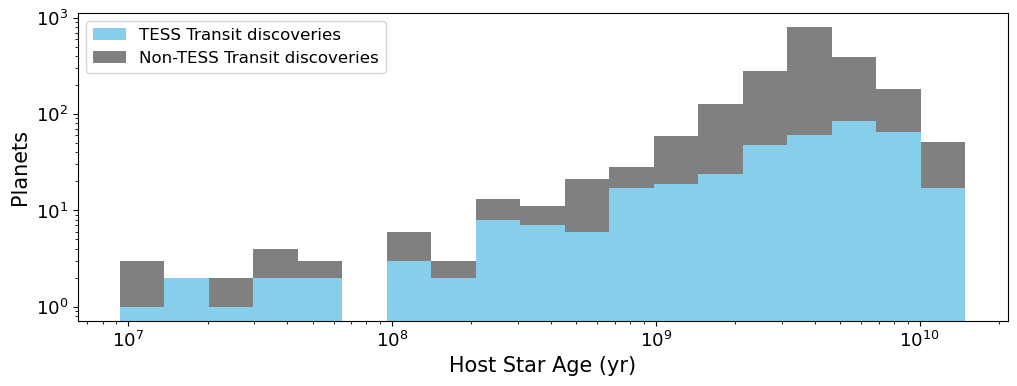

In [7]:
idx1 = (data['disc_facility'] != 'Transiting Exoplanet Survey Satellite (TESS)') & (data['discoverymethod'] == 'Transit' ) & (data['pl_letter'] == 'b') & (data['default_flag'] == True) & pd.notnull(data['st_age']) 
idx2 = (data['disc_facility'] == 'Transiting Exoplanet Survey Satellite (TESS)') & (data['discoverymethod'] == 'Transit' ) & (data['pl_letter'] == 'b') & (data['default_flag'] == True) & pd.notnull(data['st_age']) 
data1 = np.multiply(data.loc[idx1]['st_age'], 1e9)
data2 = np.multiply(data.loc[idx2]['st_age'], 1e9)

# Create log-spaced bins
bins = np.logspace(np.log10(data1.min()), np.log10(data1.max()), 20)

# Plot the histogram
plt.figure(figsize = (12,4))
plt.hist([data2, data1], bins=bins, stacked=True, color = ["SkyBlue", "Grey"])
plt.xticks(fontsize = 13)
plt.yticks(fontsize = 13)
plt.xscale('log')
plt.xlabel("Host Star Age (yr)", fontsize = 15)
plt.yscale('log')
plt.legend([ "TESS Transit discoveries","Non-TESS Transit discoveries", ], fontsize = 12)
plt.ylabel("Planets", fontsize = 15)

## Example: use Rebound to set up a simulation

In [8]:
# Read in file that gives you hex color per star temperature 
colors = pd.read_csv("colors.txt", delim_whitespace=True)

# other colors
theblack = '#293241'
thered = '#BF0603'
thegrey = '#A9ACA9'

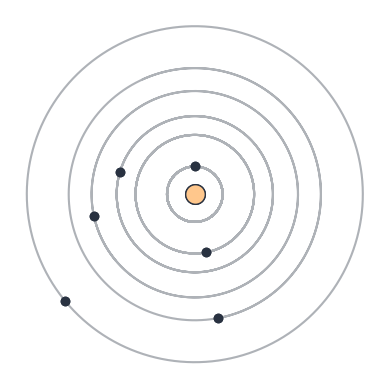

In [9]:
import rebound
sysname = 'Kepler-80'
idx = data['hostname'] == sysname
sim = rebound.Simulation()
epoch = 0
sim.add(m=data.loc[idx]['st_mass'].values[0])
for i, planet in enumerate(range(len(data.loc[idx]['st_teff'].values))):

    tmid = data.loc[idx]['pl_tranmid'].values[planet]
    if np.isnan(tmid): tmid = 0 
    per = data.loc[idx]['pl_orbper'].values[planet] / 365.25
    ecc = data.loc[idx]['pl_orbeccen'].values[planet] 
    if np.isnan(ecc): ecc = 0 
    inc = data.loc[idx]['pl_orbincl'].values[planet] 
    if np.isnan(inc): inc = 0 
    sim.add(m= 1/330000., e=ecc, P = per, inc = (90 - inc) * np.pi/ 180, # inc is recentered so that i=0 means transiting  
            M= np.pi * (90 - 360*((np.abs(epoch - tmid)) % per) / per) / 180, hash = "planet%s" %i) 
    # you could also draw planet mass, ecc, etc from the data frame
    
sim.move_to_com()

## get ready to store the data
simresults = pd.DataFrame()

x = []
y = []

times = np.linspace(epoch, epoch + per, 1000)
for timeval in times:
    sim.integrate(timeval)
    tempdict= {}
    for planet in range(len(data.loc[idx]['st_teff'].values)):
        tempdict['a%s' %planet] = sim.particles['planet%s' % planet].a
        tempdict['x%s' %planet] = sim.particles['planet%s' % planet].x
        tempdict['y%s' %planet] = sim.particles['planet%s' % planet].y
        tempdict['z%s' %planet] = sim.particles['planet%s' % planet].z
    simresults = pd.concat([simresults, pd.DataFrame(tempdict, index=[0])],    ignore_index=True)

## get the star set up
temp_for_system = round(data.loc[idx]['st_teff'].values[0]/100, 0) * 100
starcol = colors.loc[colors['Teff'] == temp_for_system]['Hex'].values[0]

plt.scatter(0,0,color=starcol, s = 200, edgecolor = theblack)
for planet in range(len(data.loc[idx]['st_teff'].values)):
    thiscol= theblack
    plt.plot(simresults['x%s' % planet].values, simresults['y%s' % planet].values, color = thiscol, alpha = 0.3)
    plt.plot(simresults['x%s' % planet].values[0], simresults['y%s' % planet].values[0], marker='o',color = thiscol)

plt.axis('off')
axes=plt.gca()
axes.set_aspect(1)


plt.scatter(0,0,color=starcol, s = 200, edgecolor = theblack)
for planet in range(len(data.loc[idx]['st_teff'].values)):
    plt.plot(simresults['x%s' % planet].values, simresults['y%s' % planet].values, color = theblack, alpha = 0.1)
    plt.plot(simresults['x%s' % planet].values[0], simresults['y%s' % planet].values[0], marker='o',color = theblack)

plt.figure()
plt.scatter(0,0,color=starcol, s = 200, edgecolor = theblack)
for planet in range(len(data.loc[idx]['st_teff'].values)):
    plt.plot(simresults['x%s' % planet].values, simresults['z%s' % planet].values, color = theblack, alpha = 0.1)
    plt.plot(simresults['x%s' % planet].values[0], simresults['z%s' % planet].values[0], marker='o',color = theblack)
plt.axis('off')
axes=plt.gca()
axes.set_aspect(1)

## Exercise: Copy one of the above examples that interests you, and change what parameters are being plotted to make your own version of the plot. 